* 진행사항? 선형 회귀 모델 ver.
  - 데이터 전처리 One-hot Encoding 등
  - 간단한 모델 먼저 사용 : Linear Regression > Ridge/Lasso/ElasticNet 
  - RMSE 등을 비교하여 성능떨어지는 모델에 대한 처리
        >> 회귀 계수가 높은 칼럼에 대하여 이상치 제거
        >> 하이퍼 파라미터 튜닝 제거

# 1. 데이터 불러오기 및 살펴보기

In [4]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# 데이터셋 불러오기
df_org=pd.read_csv('/Users/bluecloud/Documents/대학/유런/데이터셋/cleand_jobs.csv')
df=df_org.copy()
df.head(10)

,job_category,salary_in_usd,experience_level,employment_type,work_setting,company_location,company_size,job_group
0,Data Analysis,95000,Entry-level,Full-time,In-person,United States,M,0
1,Data Analysis,75000,Entry-level,Full-time,In-person,United States,M,0
2,Data Science and Research,72000,Entry-level,Full-time,Remote,United States,M,2
3,Data Science and Research,64000,Entry-level,Full-time,Remote,United States,M,2
4,Data Analysis,100000,Entry-level,Full-time,In-person,United States,M,0
5,Data Analysis,75000,Entry-level,Full-time,In-person,United States,M,0
6,Data Quality and Operations,49216,Entry-level,Full-time,Remote,United Kingdom,M,1
7,Data Quality and Operations,36912,Entry-level,Full-time,Remote,United Kingdom,M,1
8,Data Analysis,105000,Entry-level,Full-time,In-person,United States,M,0
9,Machine Learning and AI,133000,Entry-level,Full-time,In-person,United States,M,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7323 entries, 0 to 7322
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_category      7323 non-null   object
 1   salary_in_usd     7323 non-null   int64 
 2   experience_level  7323 non-null   object
 3   employment_type   7323 non-null   object
 4   work_setting      7323 non-null   object
 5   company_location  7323 non-null   object
 6   company_size      7323 non-null   object
 7   job_group         7323 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 457.8+ KB


In [8]:
df.describe()

,salary_in_usd,job_group
count,7323.000000,7323.000000
mean,151974.747781,1.541581
std,58722.047427,0.798805
min,16000.000000,0.000000
25%,110000.000000,1.000000
50%,145000.000000,2.000000
75%,190000.000000,2.000000
max,375500.000000,2.000000


- Null값 없음
- job_group을 제외한 나머지 칼럼에는 Encoding 작업이 필요할듯 >> 선형 회귀 모델에는 One-hot Encoding만
- 근데 job_group int형도 어쨋거나 0<1<2 이런식으로 순서로 받아들여질 수 있지 않나..? >> jop_group도 포함 ㄱㄱ

# 2. 데이터 전처리

### 2-1. One-hot Encoding
- 일단 타겟변수 제외하고 모든 칼럼에 One-hot Encoding 적용 

In [10]:
# One-hot Encoding for every columns
ohe_cols=["job_category", "employment_type", "work_setting", "company_location","experience_level", "company_size","job_group"]
df=pd.get_dummies(df,columns=ohe_cols,drop_first=True)

# 결과 확인
print(df.head())
print(df.info())

   salary_in_usd  job_category_Cloud and Database  job_category_Data Analysis  \
0          95000                            False                        True   
1          75000                            False                        True   
2          72000                            False                       False   
3          64000                            False                       False   
4         100000                            False                        True   

   job_category_Data Architecture and Modeling  job_category_Data Engineering  \
0                                        False                          False   
1                                        False                          False   
2                                        False                          False   
3                                        False                          False   
4                                        False                          False   

   job_category_Data Manag

### 2-2. 타겟값 로그변환

<Axes: title={'center': 'org salary Histogram'}, xlabel='salary_in_usd', ylabel='Density'>

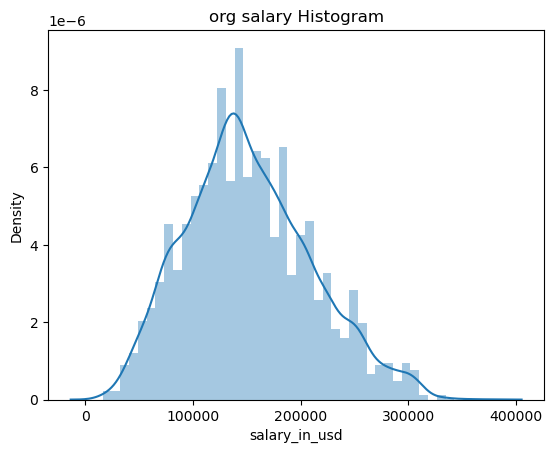

In [14]:
plt.title('org salary Histogram')
sns.distplot(df['salary_in_usd'])

- 엥 나름 저정도면 중심에서 덜 치우친 편 아닌가..?그래도 정규 분포는 아니니께.. >> 로그변환

<Axes: title={'center': 'log transformed salary Histogram'}, xlabel='salary_in_usd', ylabel='Density'>

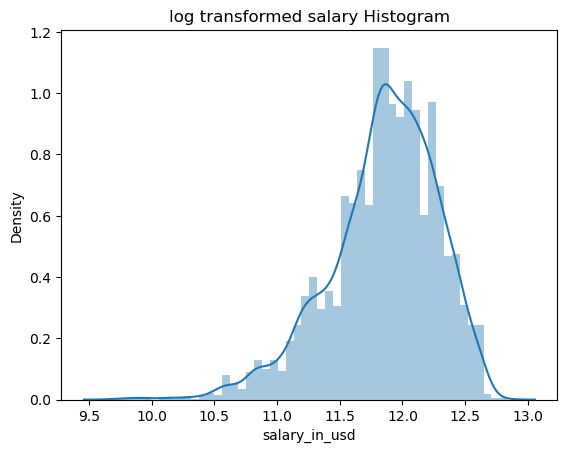

In [18]:
plt.title('log transformed salary Histogram')
log_salary=np.log1p(df['salary_in_usd'])
sns.distplot(log_salary)

??? 로그 변환 vs 아닌거 비교 해봐야지

In [22]:
# 일단 변환
df['salary_in_usd']=np.log1p(df['salary_in_usd'])
df.head(10)

,salary_in_usd,job_category_Cloud and Database,job_category_Data Analysis,job_category_Data Architecture and Modeling,job_category_Data Engineering,job_category_Data Management and Strategy,job_category_Data Quality and Operations,job_category_Data Science and Research,job_category_Leadership and Management,job_category_Machine Learning and AI,...,company_location_Ukraine,company_location_United Kingdom,company_location_United States,experience_level_Executive,experience_level_Mid-level,experience_level_Senior,company_size_M,company_size_S,job_group_1,job_group_2
0,2.522655,False,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
1,2.503504,False,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
2,2.500159,False,False,False,False,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,True
3,2.490446,False,False,False,False,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,True
4,2.526763,False,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
5,2.503504,False,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
6,2.468438,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,True,False,True,False
7,2.443765,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,True,False,True,False
8,2.530655,False,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
9,2.549298,False,False,False,False,False,False,False,False,True,...,False,False,True,False,False,False,True,False,False,True


# 3. 모델 학습/예측/평가

### 3-1.여러 모델의 로그 변환된 RMSE 측정하는 함수
- 이때 학습 후 로그 변환된 y_test,y_pred 값을 다시 expm1으로 스케일 변환시켜야함

In [68]:
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
# 성능 저장을 위한 리스트
results = []

# 성능 평가 함수
def evaluate_model(y_test, y_pred, model_name):
    y_test_exmp=np.expm1(y_test)
    y_pred_exmp=np.expm1(y_pred)
    mae = mean_absolute_error(y_test_exmp, y_pred_exmp)
    rmse = np.sqrt(mean_squared_error(y_test_exmp, y_pred_exmp))
    r2 = r2_score(y_test_exmp, y_pred_exmp)
    
    results.append({"Model": model_name, "MAE": mae, "RMSE": rmse, "R² Score": r2})

### 3-2. 타겟과 피처 설정(8:2)

In [70]:
y=df['salary_in_usd']
X=df.drop('salary_in_usd',axis=1,inplace=False)

#데이터 분할 8:2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156)

In [72]:
# 1. 선형회귀
lf=LinearRegression()
lf.fit(X_train,y_train)
y_pred_lf=lf.predict(X_test)
evaluate_model(y_test,y_pred_lf,"Linear Regression")

# 2. 릿지회귀
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
y_pred_ridge=ridge.predict(X_test)
evaluate_model(y_test,y_pred_ridge,"Ridge")

# 3. 라쏘회귀
lasso=Lasso(alpha=0.1)
lasso.fit(X_train,y_train)
y_pred_lasso=lasso.predict(X_test)
evaluate_model(y_test,y_pred_lasso,"Lasso")

# 4. 엘라스틱넷회귀
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)
evaluate_model(y_test, y_pred_elastic, "ElasticNet Regression")

# 5. 랜덤포레스트
rf= RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model(y_test, y_pred_rf, "Random Forest Regression")

In [74]:
# 결과 비교
df_results=pd.DataFrame(results)
print(df_results)

                      Model       MAE      RMSE  R² Score
0         Linear Regression  0.263875  0.328856  0.425146
1                     Ridge  0.263768  0.328881  0.425061
2                     Lasso  0.336939  0.433752 -0.000065
3     ElasticNet Regression  0.336737  0.433493  0.001127
4  Random Forest Regression  0.259328  0.323820  0.442618


### 3-3. 회귀 계수 피처로 시각화 하기

In [106]:
def get_coef(model,n=10):
    coef=pd.Series(model.coef_,index=X.columns)
    coef=coef[coef!=0]
    #상위 10개, 하위 10개 추출해 반환
    coef_top=coef.sort_values(ascending=False).head(n)
    coef_bottom=coef.sort_values(ascending=False).tail(n)
    return coef_top,coef_bottom

def visualize_coef(models):
    for model in models:
        # 상위 10개, 하위 10개 회귀 계수를 구하고, 이를 concat으로 결합
        coef_high, coef_low = get_coef(model)
        coef_concat = pd.concat([coef_high, coef_low])

        # 개별 그래프 생성
        plt.figure(figsize=(12, 6))  # 모델별 개별 크기 설정
        sns.barplot(x=coef_concat.values, y=coef_concat.index, palette="viridis")
        plt.title(f'{model.__class__.__name__} Coefficients', fontsize=18)
        plt.xlabel("Coefficient Value", fontsize=14)
        plt.ylabel("Feature", fontsize=14)
        plt.grid(True, linestyle="--", alpha=0.5)

        # 그래프 표시
        plt.show()

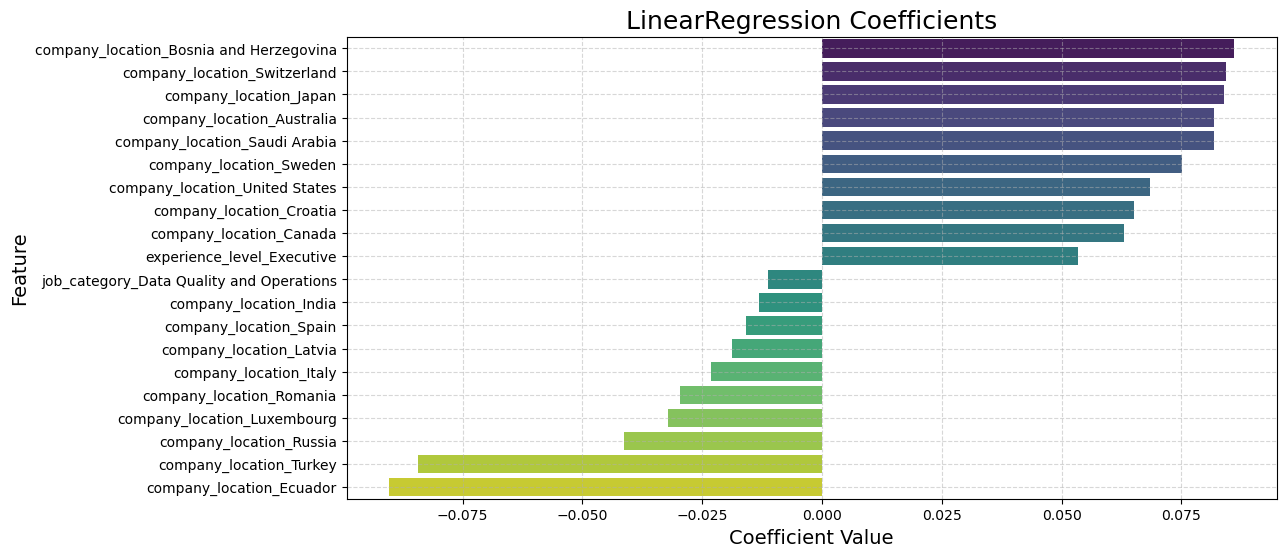

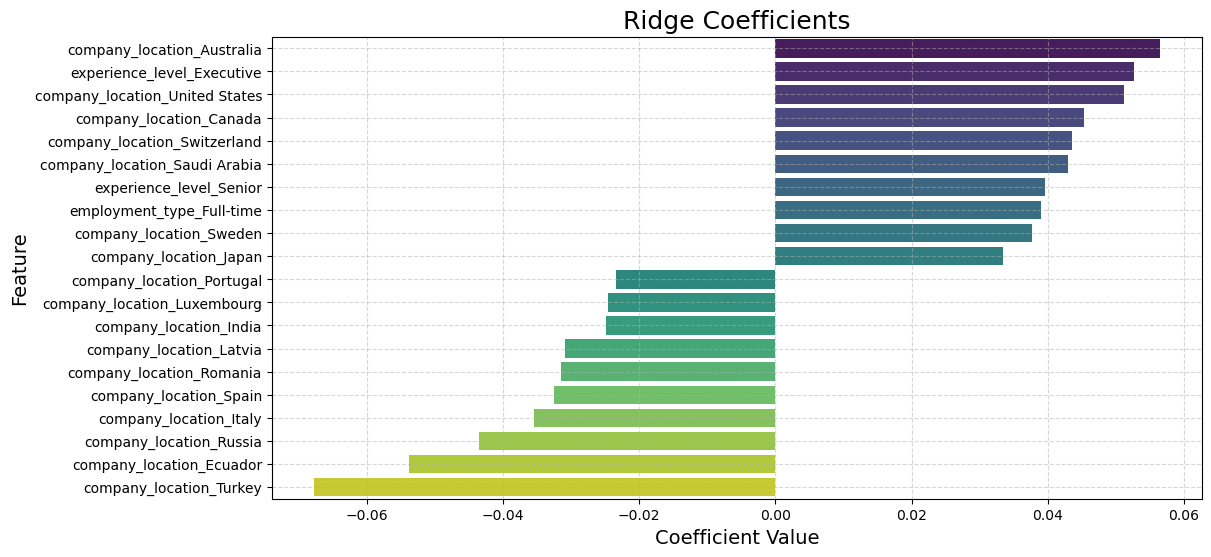

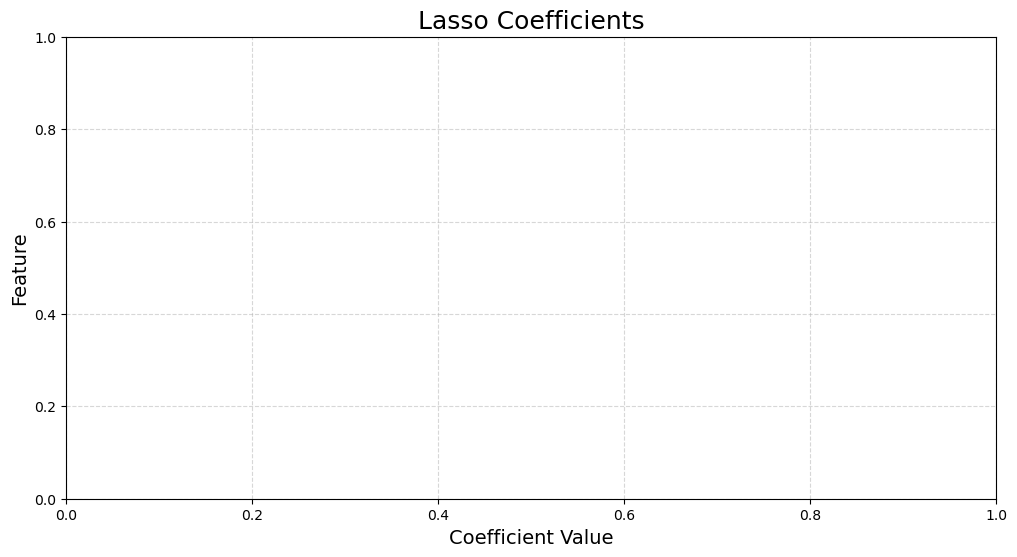

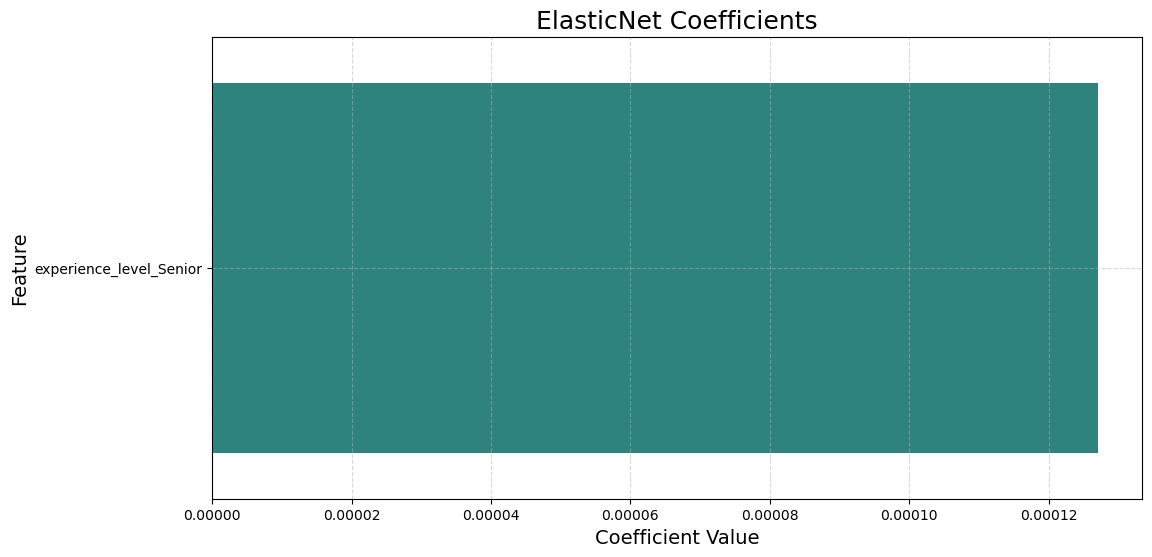

In [108]:
# 앞에서 학습한 모델의 회귀 계수 시각화
models=[lf,ridge,lasso,elastic]
visualize_coef(models)